# **Setup**

### **Imports**

In [26]:
import numpy as np
import pandas as pd
import sys

# Point Python to this path
sys.path.append('../src')

from data_utils import download_data, load_metadata, create_side_contrast_table
from decoders import decode
from plotting import plot_distribution_of_decoding_score, plot_region_score_per_session
from plotting import plot_region_decoding, plot_group_decoding, plot_decoding_heatmap
from plotting import plot_significant_periods, plot_decoding_onset, plot_peak_decoding
from plotting import plot_decoding_duration, plot_onset_comparison, plot_peak_comparison
from plotting import plot_duration_comparison
from preprocessing import region_level_aggregation, anatomical_grouping
from stats import statistical_analysis, extract_significant_periods, summarize_decoding

# This is to view dataframe interactively in Google Colab
if 'google.colab' in sys.modules:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()

# This is to style figures
if sys.version_info >= (3, 10):
    from ibl_style.style import figure_style
    figure_style()

### **Downloading/loading the data for stimulus onset**

In [ ]:
# Download the data
download_data('stimOn')

In [2]:
meta = load_metadata('stimOn')
print(f'Meta data contains the following keys: {list(meta.keys())}')

Meta data contains the following keys: ['clusters', 'trials', 'sessions', 'times', 'nbins', 'dt', 'data_path']


# **Decoding**

In [3]:
WIN = 0.1
STEP = 0.05

centers = np.arange(meta.times[0] + WIN / 2, meta.times[-1] - WIN / 2, STEP)
print(f"Number of windows: {len(centers)}")
centers

Number of windows: 28


array([-0.445, -0.395, -0.345, -0.295, -0.245, -0.195, -0.145, -0.095,
       -0.045,  0.005,  0.055,  0.105,  0.155,  0.205,  0.255,  0.305,
        0.355,  0.405,  0.455,  0.505,  0.555,  0.605,  0.655,  0.705,
        0.755,  0.805,  0.855,  0.905])

## **Side Decoder**

In [ ]:
# !! TO SKIP HEAVY PROCESSING !!
# Run this cell only ONCE for the decoder to save its results
side_results_df = decode(meta, centers, 'side', WIN)

# Save the results as CSV
side_results_df.to_csv('../results/side_decoding_results.csv', index=False)

In [4]:
# And then use this cell from there on to load the results
side_results_df = pd.read_csv('../results/side_decoding_results.csv')
side_results_df.head()

,index,region,eid,center,score
0,0,MG,09b2c4d1-058d-4c84-9fd4-97530f85baf6,-0.445,0.506299
1,1,MG,09b2c4d1-058d-4c84-9fd4-97530f85baf6,-0.395,0.469463
2,2,MG,09b2c4d1-058d-4c84-9fd4-97530f85baf6,-0.345,0.516385
3,3,MG,09b2c4d1-058d-4c84-9fd4-97530f85baf6,-0.295,0.533433
4,4,MG,09b2c4d1-058d-4c84-9fd4-97530f85baf6,-0.245,0.587584


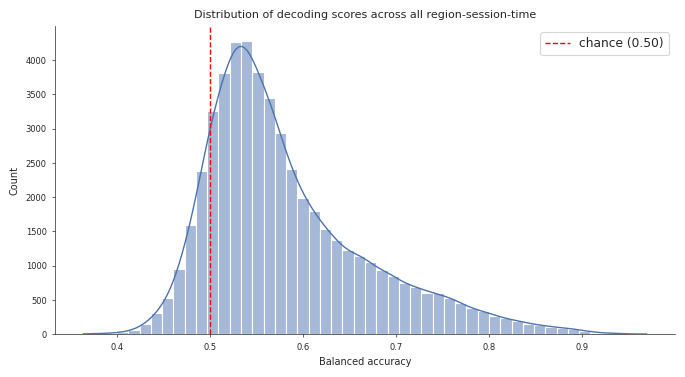

In [5]:
plot_distribution_of_decoding_score(side_results_df, 'side')

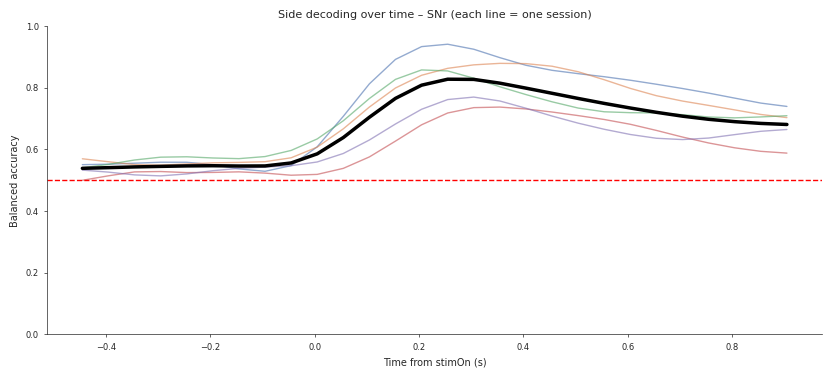

In [6]:
plot_region_score_per_session(side_results_df, ['SNr'], 'side')

## **Contrast Decoder**

In [ ]:
# !! TO SKIP HEAVY PROCESSING !!
# Run this cell only ONCE for the decoder to save its results
contrast_results_df = decode(meta, centers, 'contrast', WIN)

# Save the results as CSV
contrast_results_df.to_csv('../results/contrast_decoding_results.csv', index=False)

In [7]:
# And then use this cell from there on to load the results
contrast_results_df = pd.read_csv('../results/contrast_decoding_results.csv')
contrast_results_df.head()

,index,region,eid,center,score
0,0,MG,09b2c4d1-058d-4c84-9fd4-97530f85baf6,-0.445,0.199195
1,1,MG,09b2c4d1-058d-4c84-9fd4-97530f85baf6,-0.395,0.221320
2,2,MG,09b2c4d1-058d-4c84-9fd4-97530f85baf6,-0.345,0.201827
3,3,MG,09b2c4d1-058d-4c84-9fd4-97530f85baf6,-0.295,0.166290
4,4,MG,09b2c4d1-058d-4c84-9fd4-97530f85baf6,-0.245,0.198429


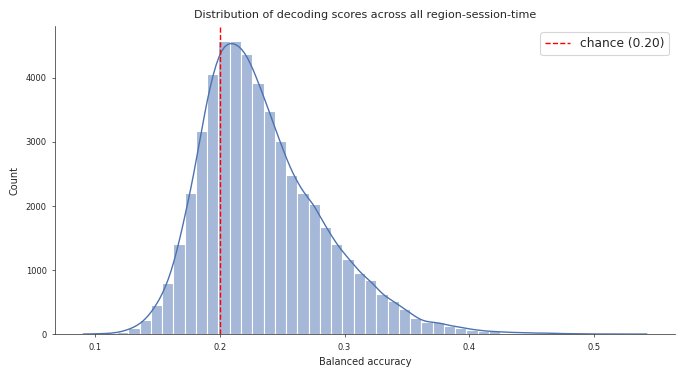

In [8]:
plot_distribution_of_decoding_score(contrast_results_df, 'contrast')

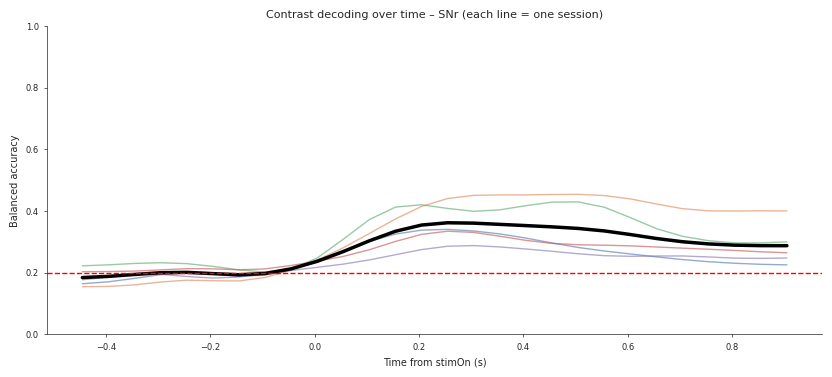

In [9]:
plot_region_score_per_session(contrast_results_df, ['SNr'], 'contrast')

# **Analysis**

### **Region-level aggregation**

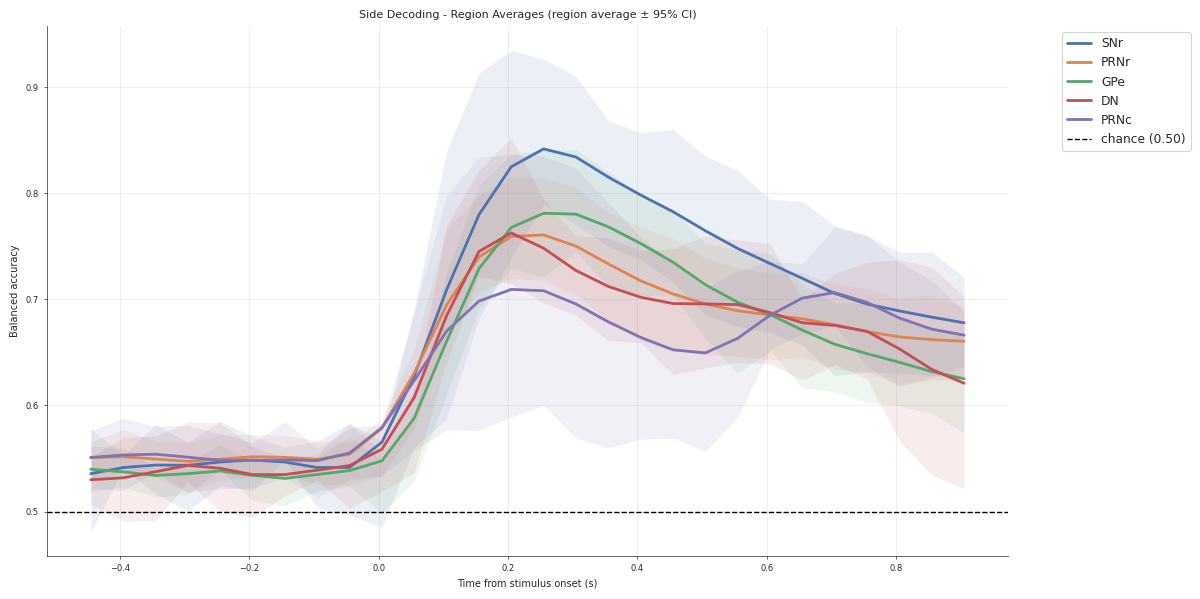

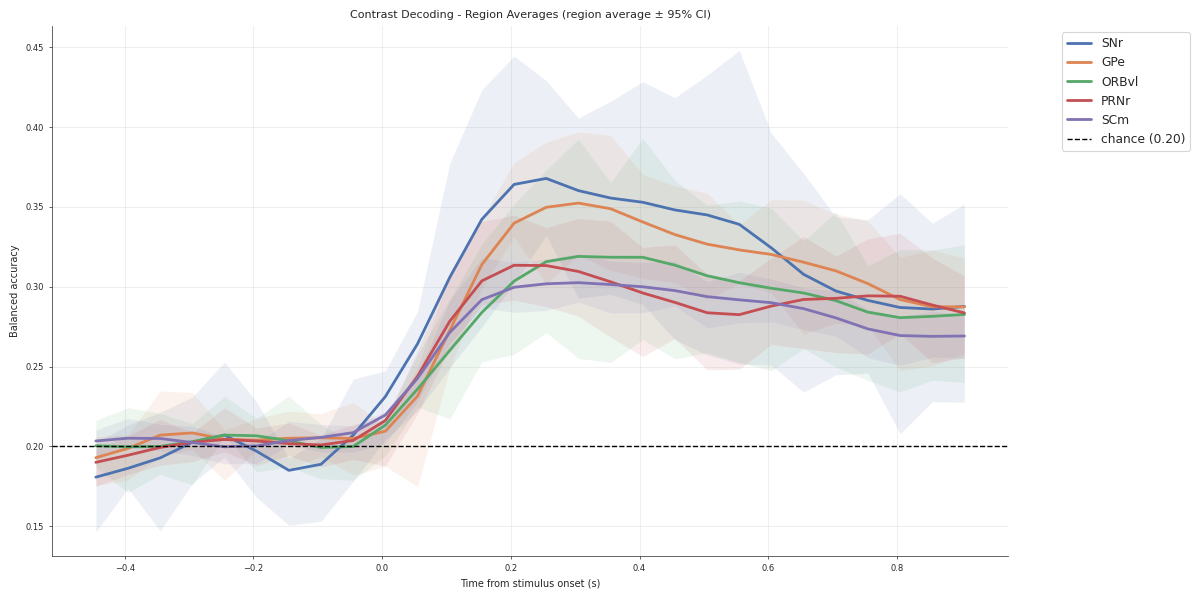

In [10]:
# SIDE
rl_agg_side = region_level_aggregation(side_results_df)

# Plot
plot_region_decoding(rl_agg_side, 'Side', 0.50, num_top_region=5)

# CONTRAST
rl_agg_contrast = region_level_aggregation(contrast_results_df)

# Plot
plot_region_decoding(rl_agg_contrast, 'Contrast', 0.20, num_top_region=5)

### **Anatomical grouping**

In [11]:
anatomical_regions = {
    'Visual thalamus': ['LGd', 'LGv', 'LP'],
    'Visual midbrain': ['NOT', 'OP', 'SCs', 'APN'],
    'Primary visual cortex': ['VISp'],
    'Higher visual cortex': [
        'VISl', 'VISli', 'VISal', 'VISam', 'VISa',
        'VISpm', 'VISrl', 'VISpl', 'VISpor'
    ],
    'Later midbrain / hindbrain': [
        'MRN', 'SCm', 'PRNr', 'PRNc', 'GRN', 'IRN', 'PGRN'
    ],
    'Association / action': [
        'RSPv', 'RSPd', 'RSPagl', 'ACAd', 'ACAv', 'MOs', 'CP'
    ]
}

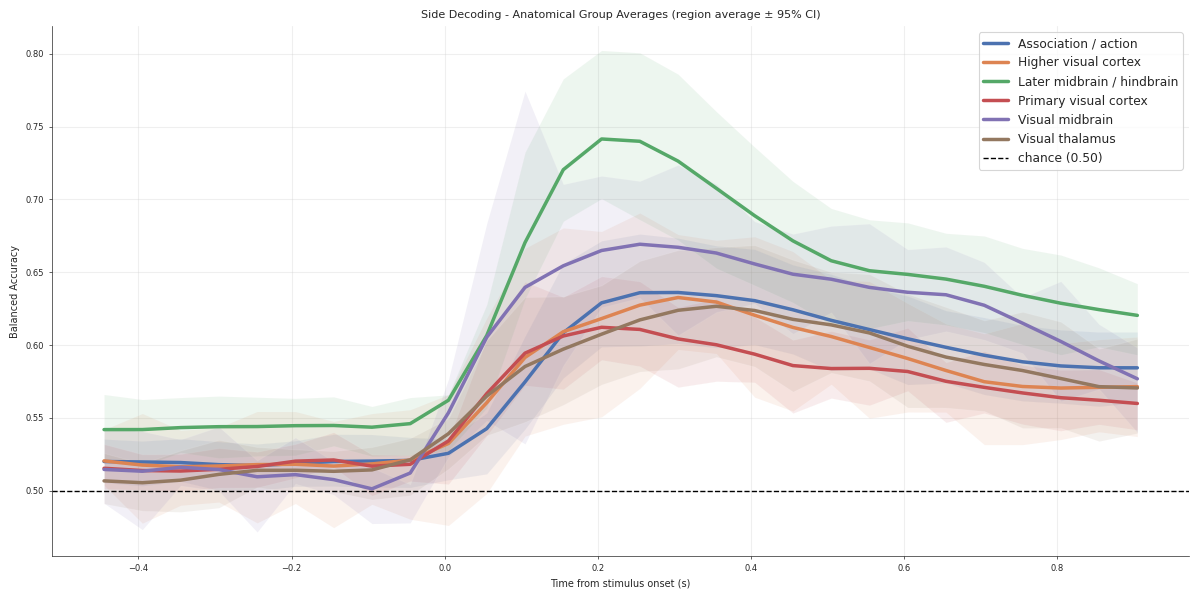

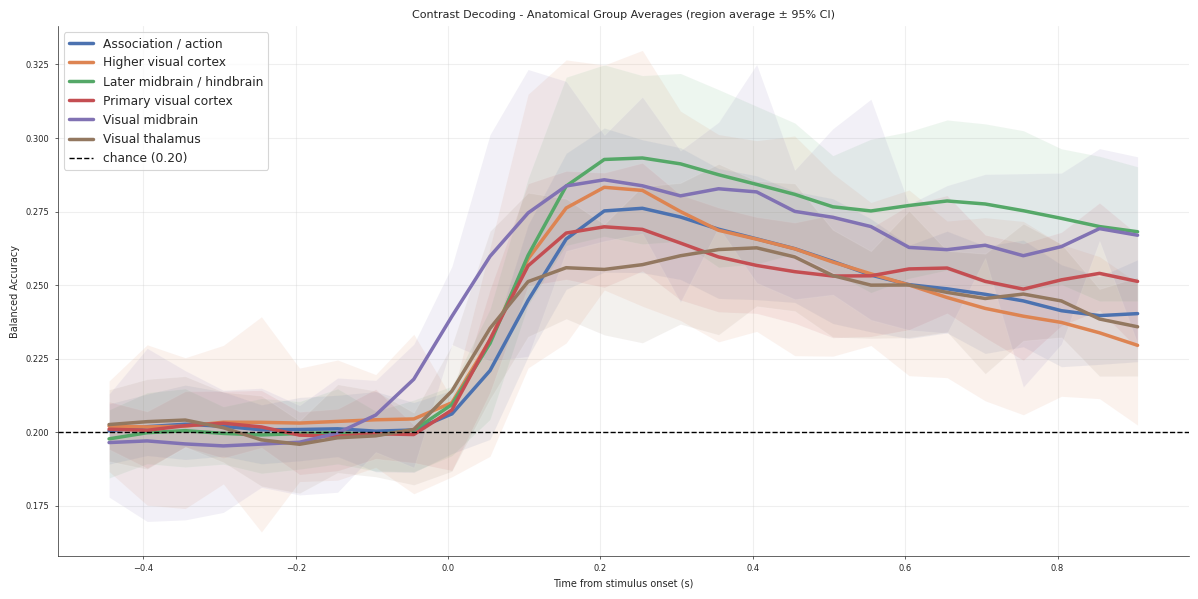

In [12]:
# SIDE
reag_grouped_side = anatomical_grouping(rl_agg_side, anatomical_regions)

# Plot
plot_group_decoding(reag_grouped_side, 0.50, 'Side')

# CONTRAST
reag_grouped_contrast = anatomical_grouping(rl_agg_contrast, anatomical_regions)

# Plot
plot_group_decoding(reag_grouped_contrast, 0.20, 'Contrast')

### **Heatmap**

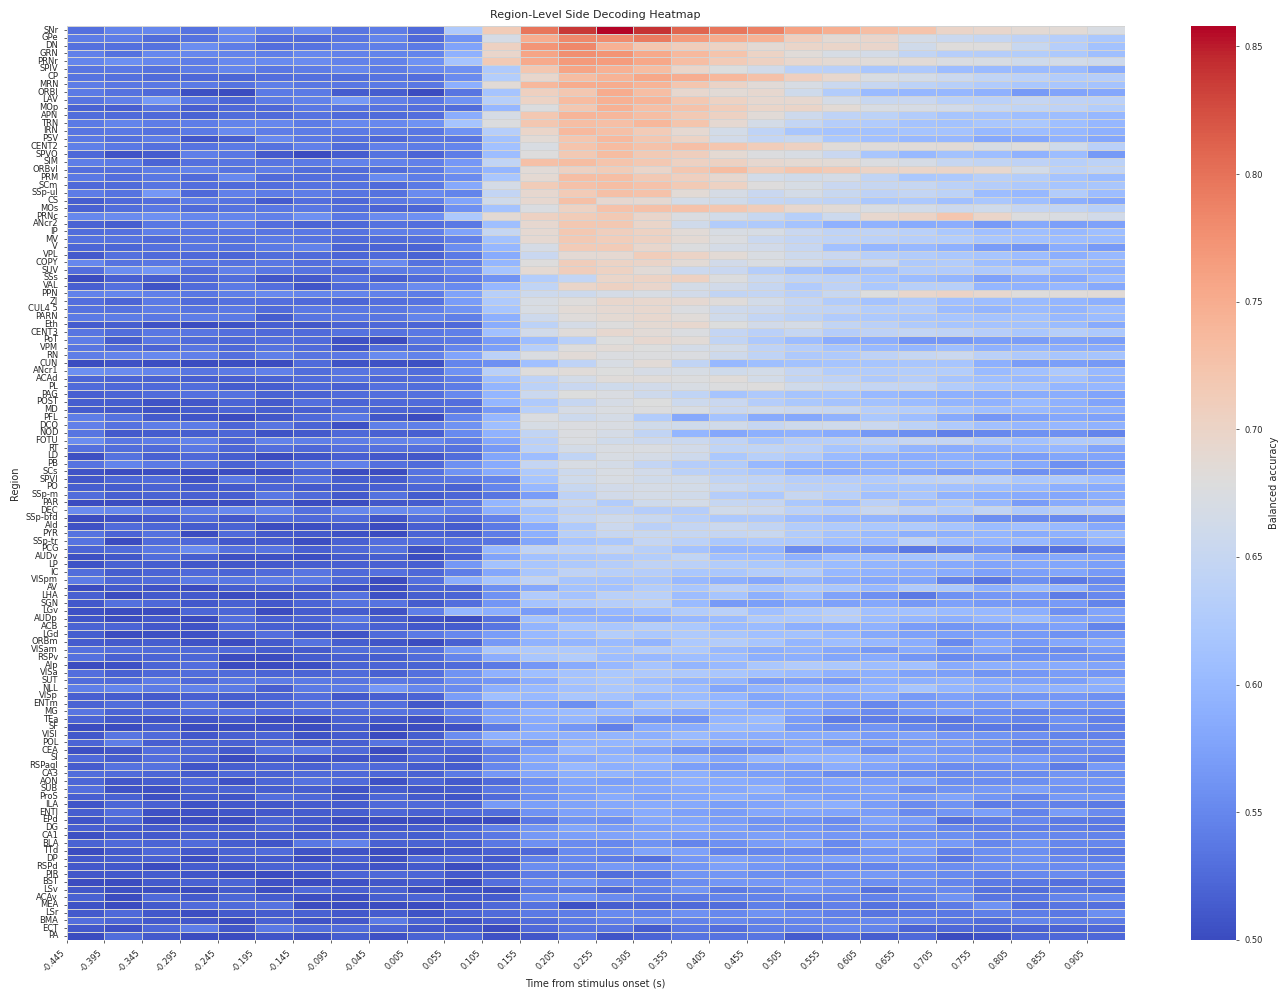

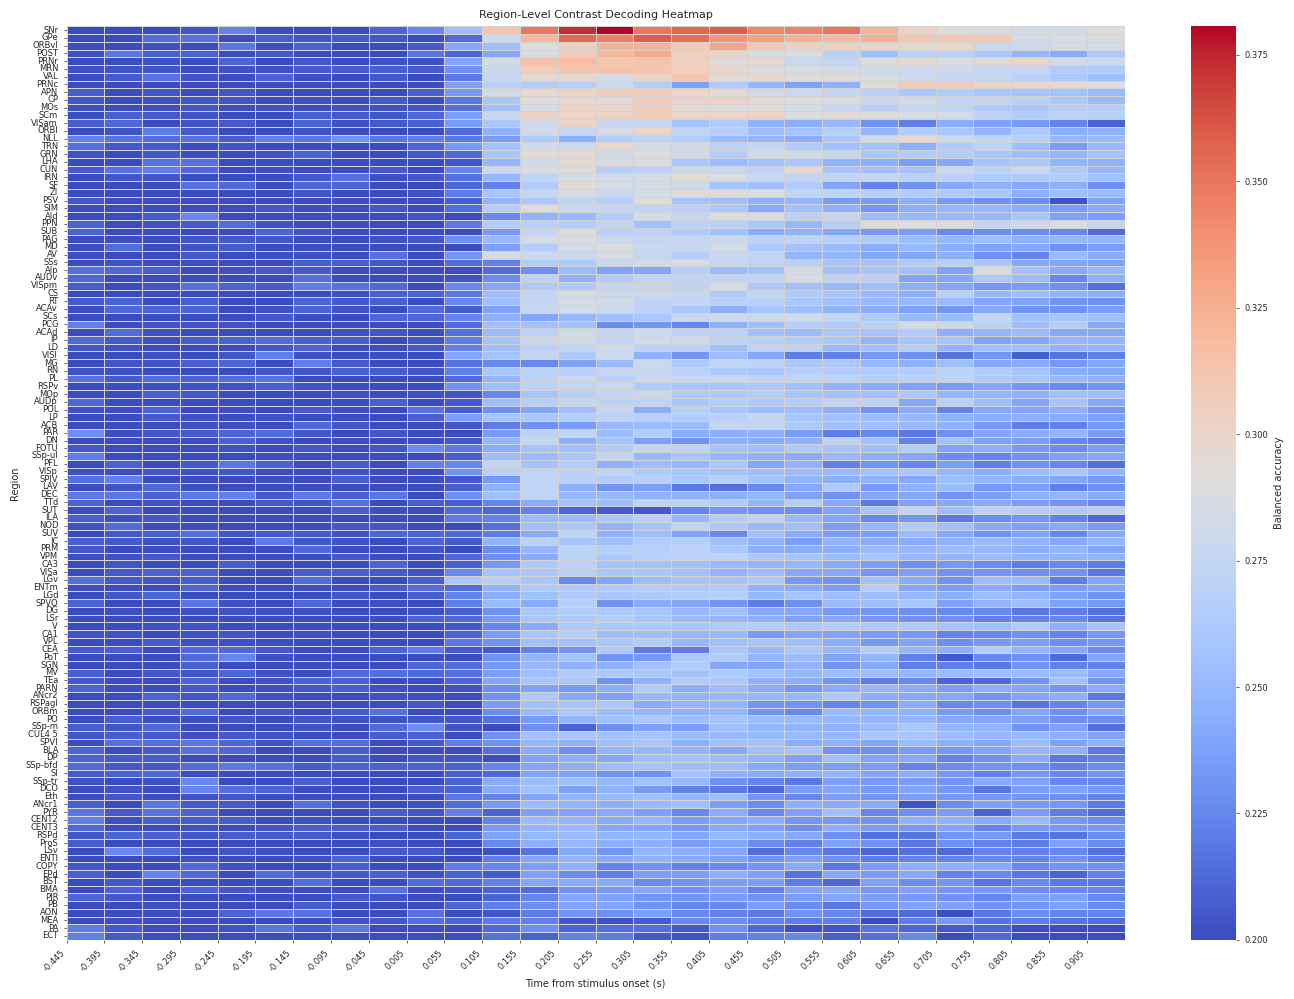

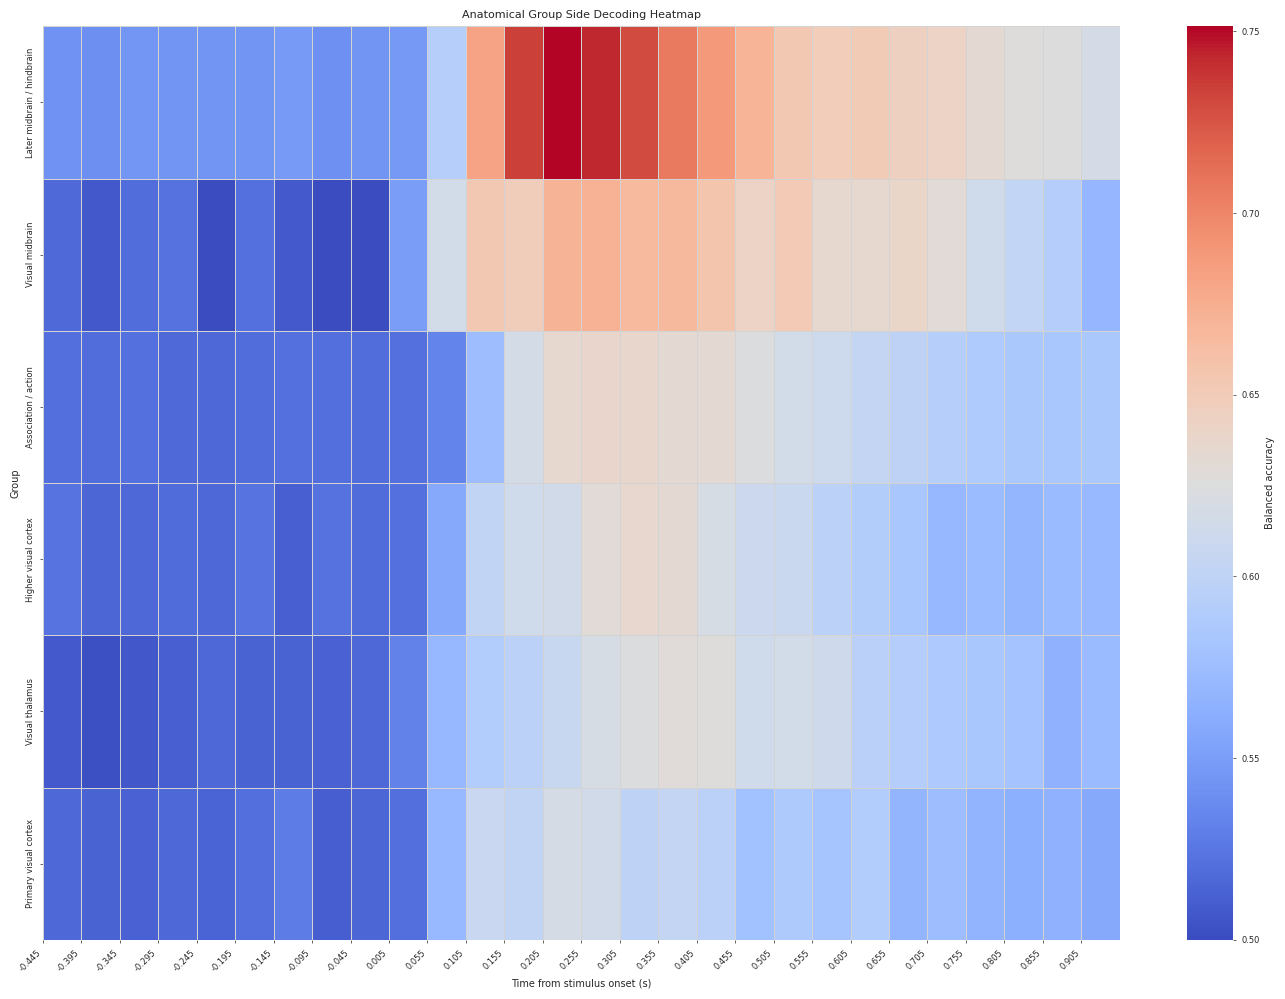

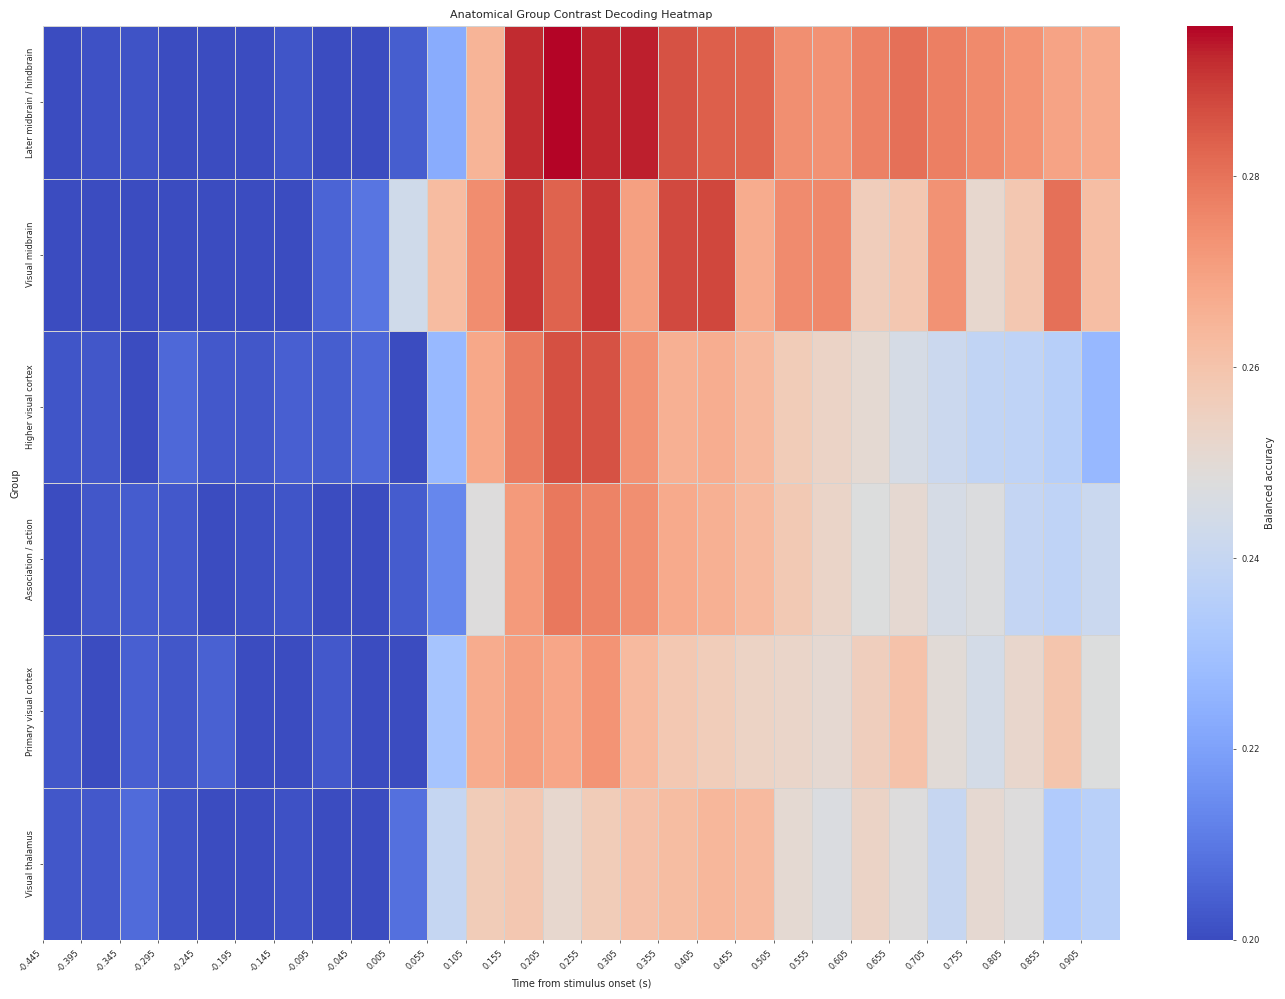

In [13]:
# SIDE Plot - Region
pivot = plot_decoding_heatmap(rl_agg_side, 'Region-Level Side', 0.50, 'region')

# CONTRAST Plot - Region
pivot = plot_decoding_heatmap(rl_agg_contrast, 'Region-Level Contrast', 0.20, 'region')

# SIDE Plot - Group
pivot = plot_decoding_heatmap(reag_grouped_side, 'Anatomical Group Side', 0.50, 'group')

# CONTRAST Plot - Group
pivot = plot_decoding_heatmap(reag_grouped_contrast, 'Anatomical Group Contrast', 0.20, 'group')

### **Statistical Validation and Identifying Significant Periods**

In [14]:
# SIDE
side_stats_df = statistical_analysis(side_results_df, 'side')
side_sig_periods = extract_significant_periods(side_stats_df)

# CONTRAST
contrast_stats_df = statistical_analysis(contrast_results_df, 'contrast')
contrast_sig_periods = extract_significant_periods(contrast_stats_df)

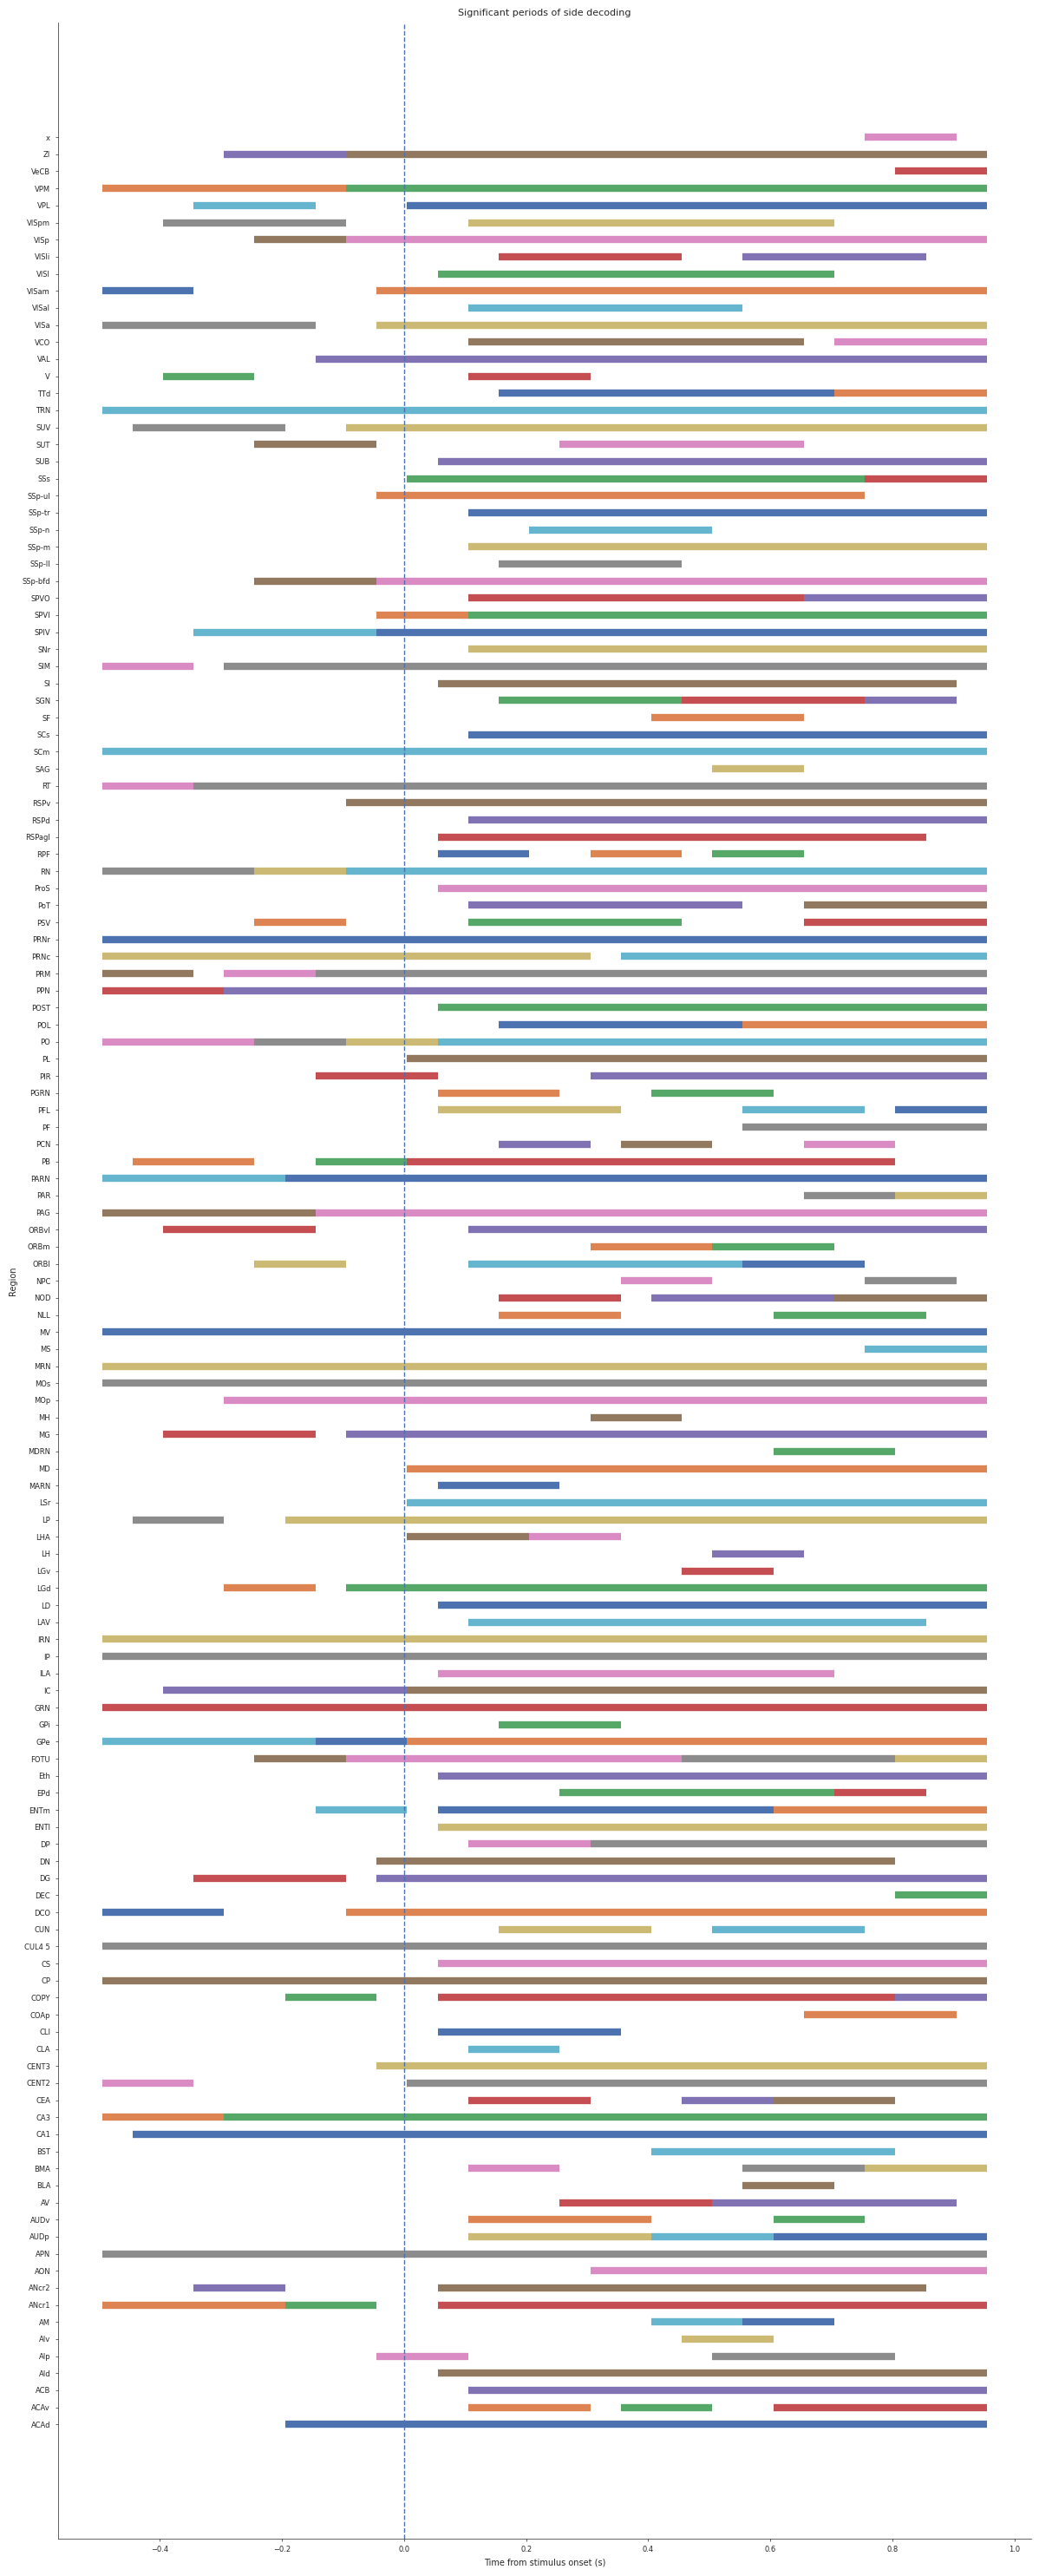

In [16]:
plot_significant_periods(side_sig_periods, 'Significant periods of side decoding')

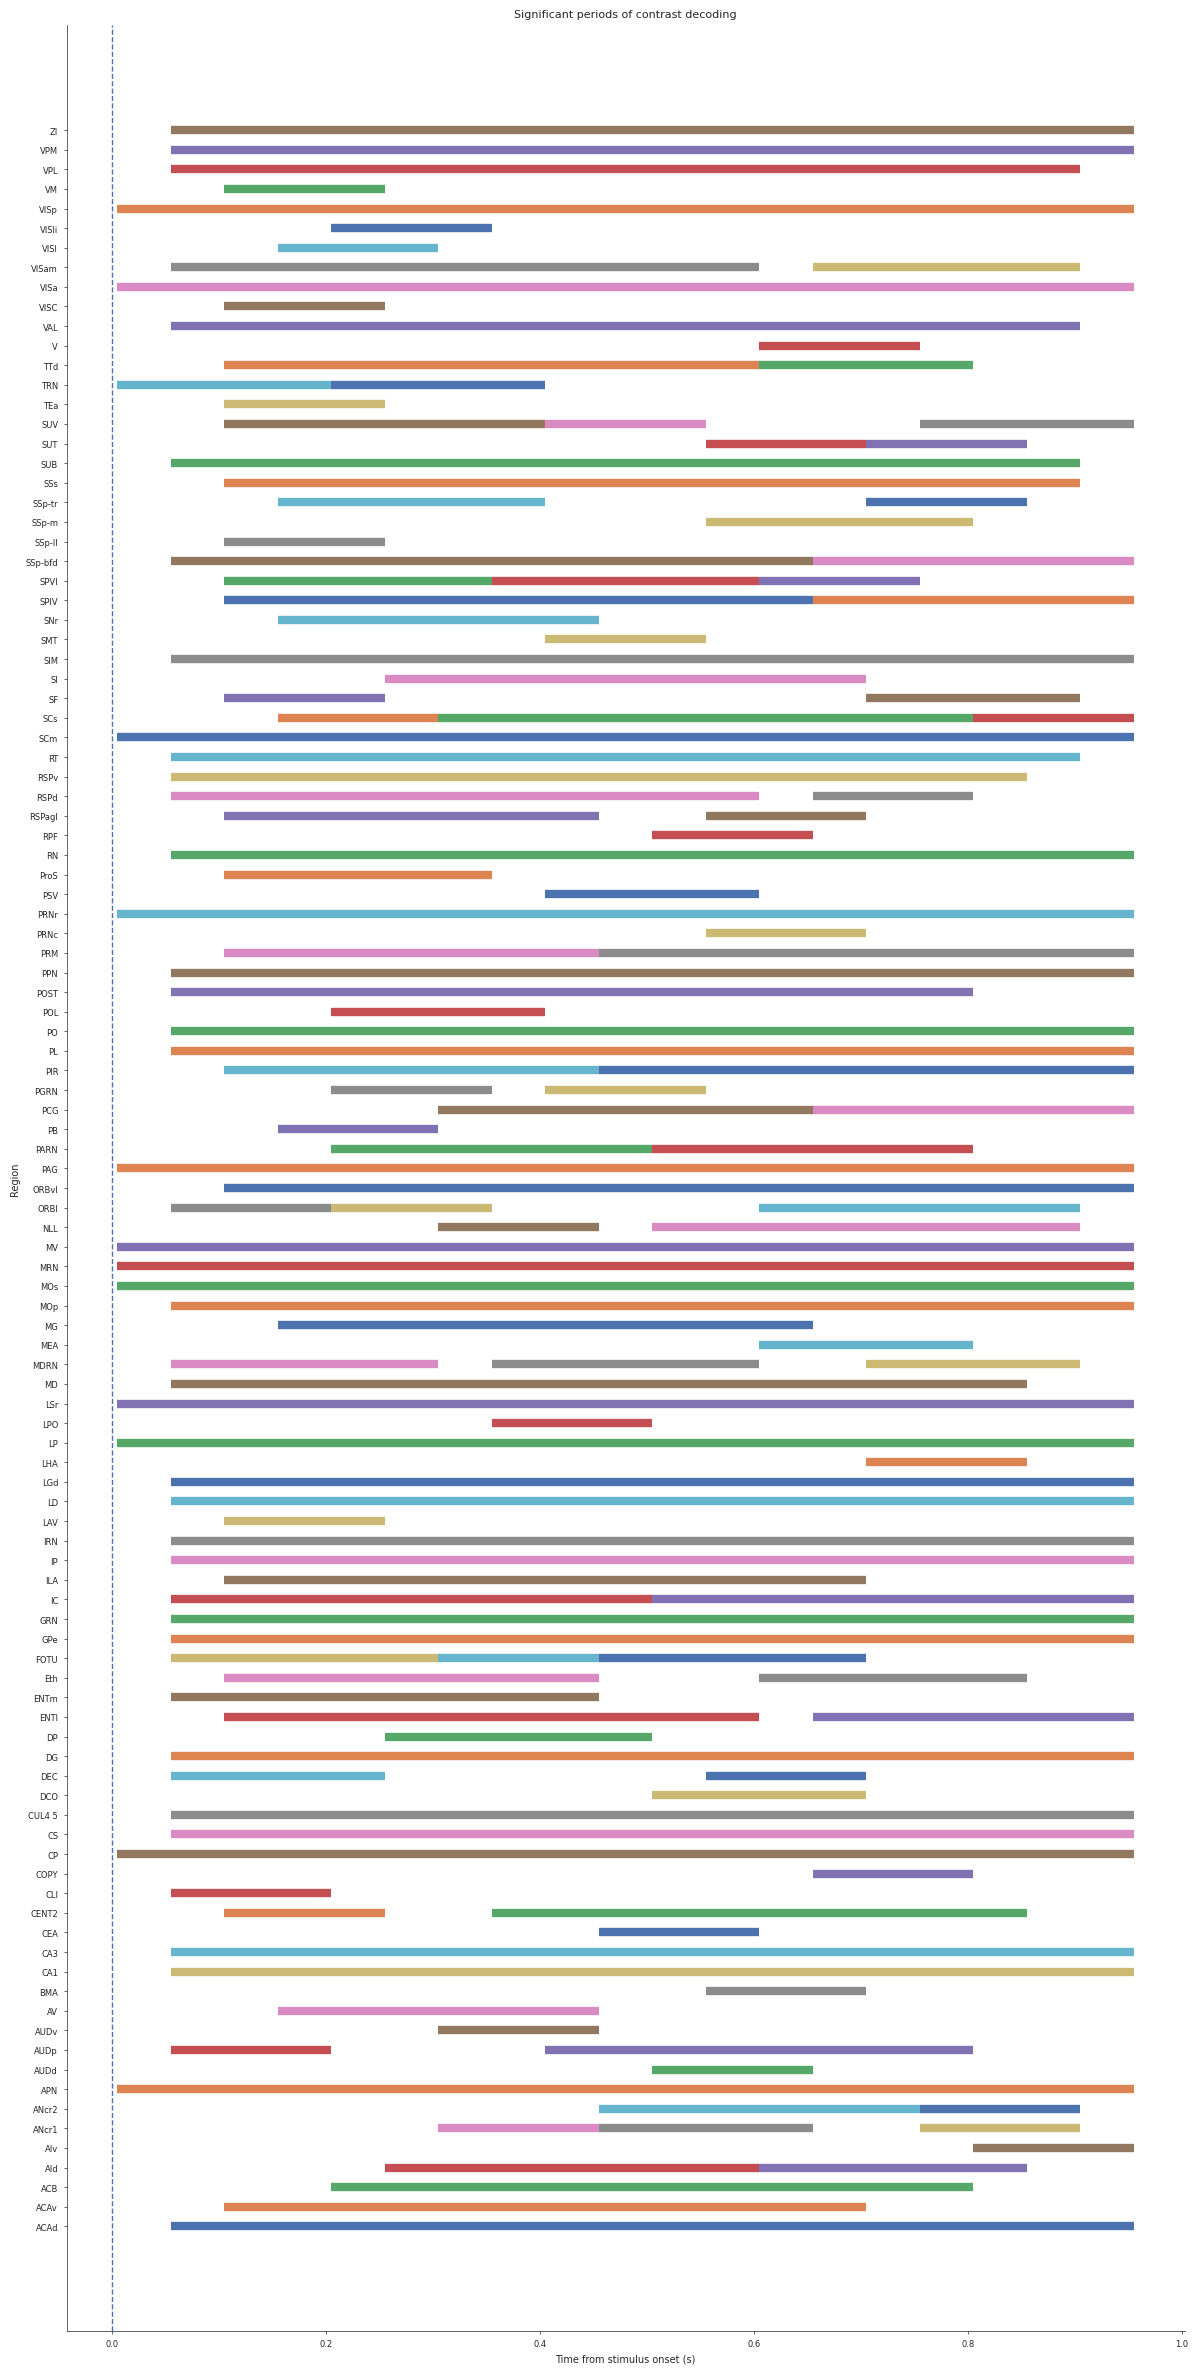

In [17]:
plot_significant_periods(contrast_sig_periods, 'Significant periods of contrast decoding')

### **Summarizing the Significant Decoding Dynamics**

In [19]:
side_summary = summarize_decoding(side_stats_df, side_sig_periods)

contrast_summary = summarize_decoding(contrast_stats_df, contrast_sig_periods)

In [20]:
print(side_summary.head())
print(contrast_summary.head())

  region  onset  offset  total_duration  peak_score  peak_center  \
0   ACAd -0.195   0.955            1.15    0.682102        0.305   
1   ACAv  0.105   0.955            0.70    0.563251        0.205   
2    ACB  0.105   0.955            0.85    0.629393        0.305   
3    AId  0.055   0.955            0.90    0.655211        0.255   
4    AIp -0.045   0.805            0.45    0.626379        0.505   

       peak_time  
0  0.255 - 0.355  
1  0.155 - 0.255  
2  0.255 - 0.355  
3  0.205 - 0.305  
4  0.455 - 0.555  
  region  onset  offset  total_duration  peak_score  peak_center  \
0   ACAd  0.055   0.955            0.90    0.282026        0.205   
1   ACAv  0.105   0.705            0.60    0.282587        0.205   
2    ACB  0.205   0.805            0.60    0.274879        0.405   
3    AId  0.255   0.855            0.60    0.290682        0.405   
4    AIv  0.805   0.955            0.15    0.260189        0.355   

       peak_time  
0  0.155 - 0.255  
1  0.155 - 0.255  
2  0.355 - 

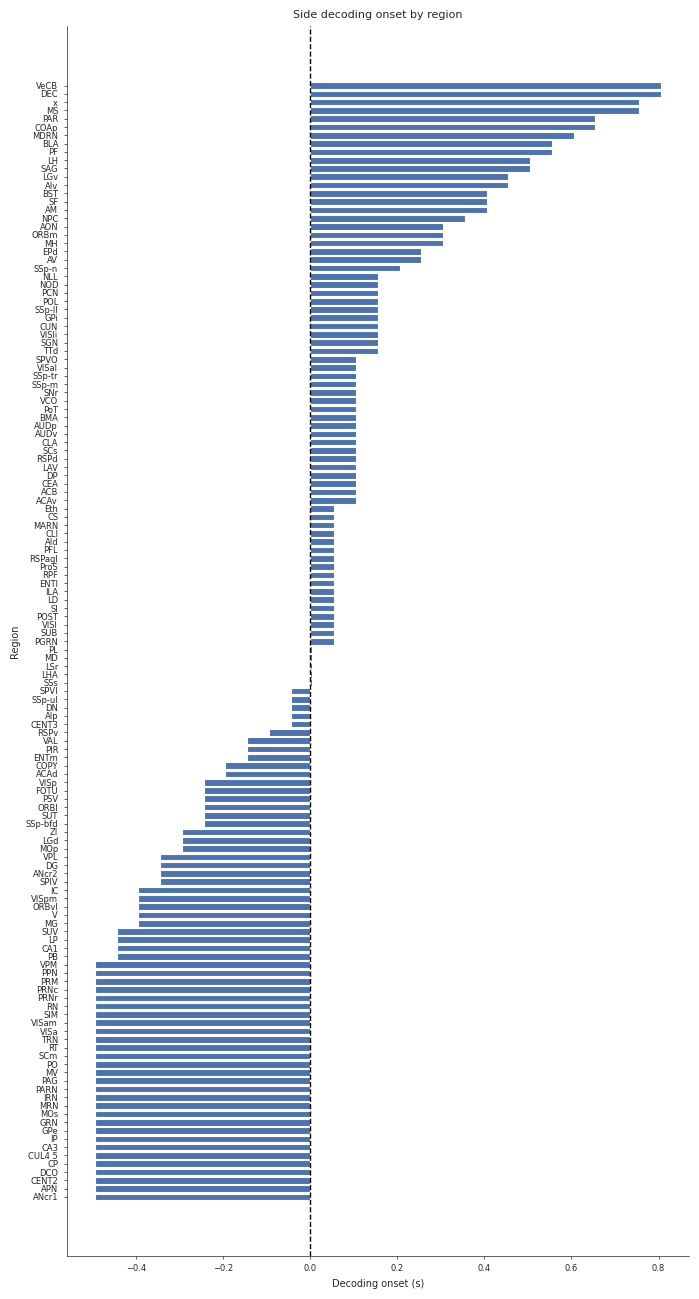

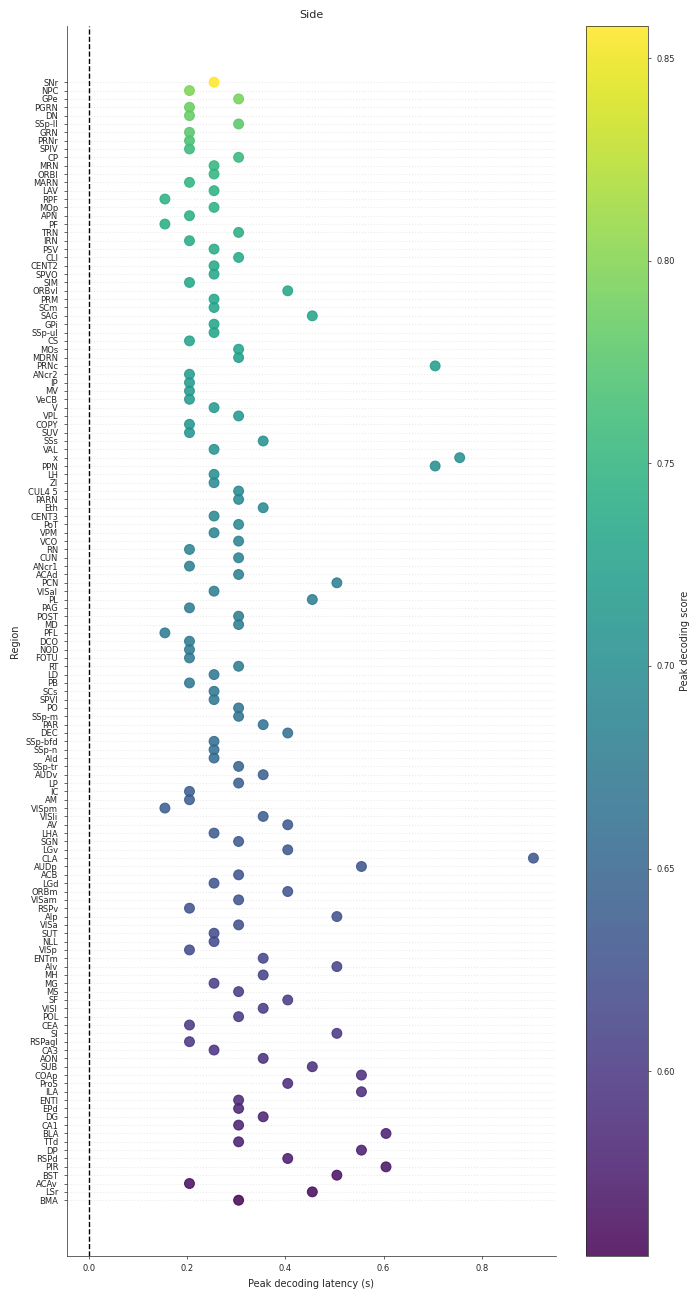

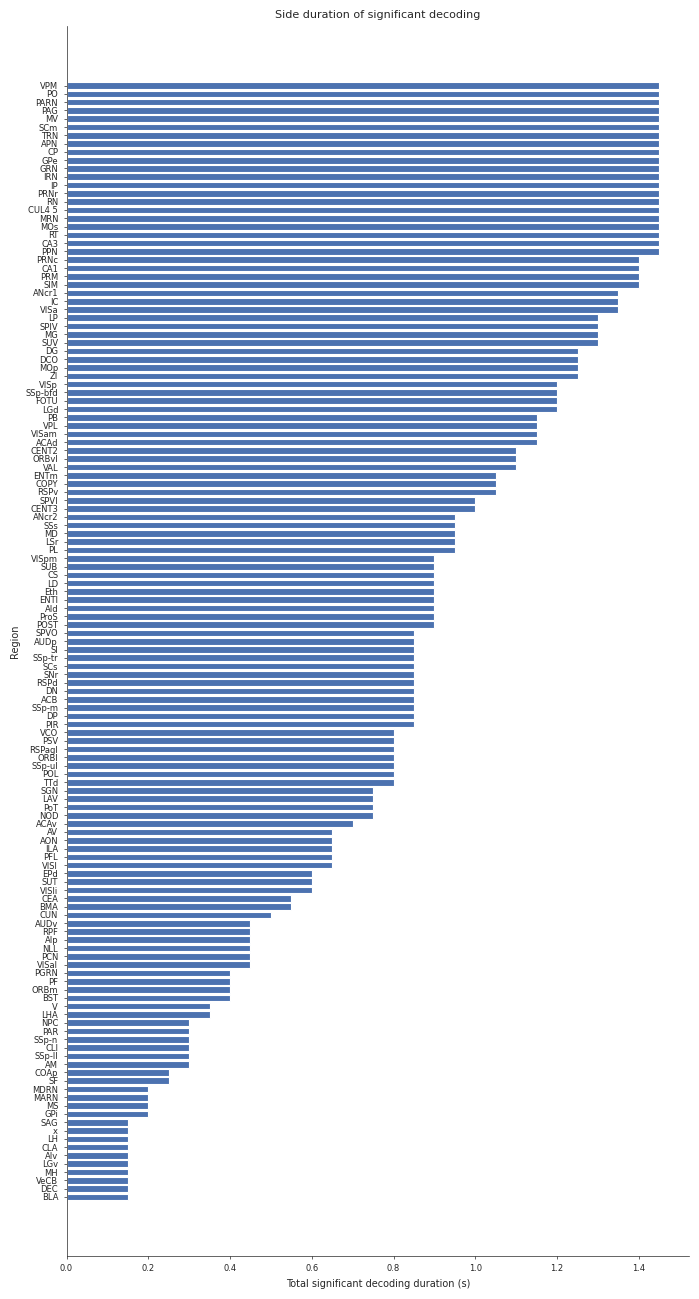

In [22]:
# SIDE
plot_decoding_onset(side_summary, title='Side')
plot_peak_decoding(side_summary, title='Side')
plot_decoding_duration(side_summary, title='Side')

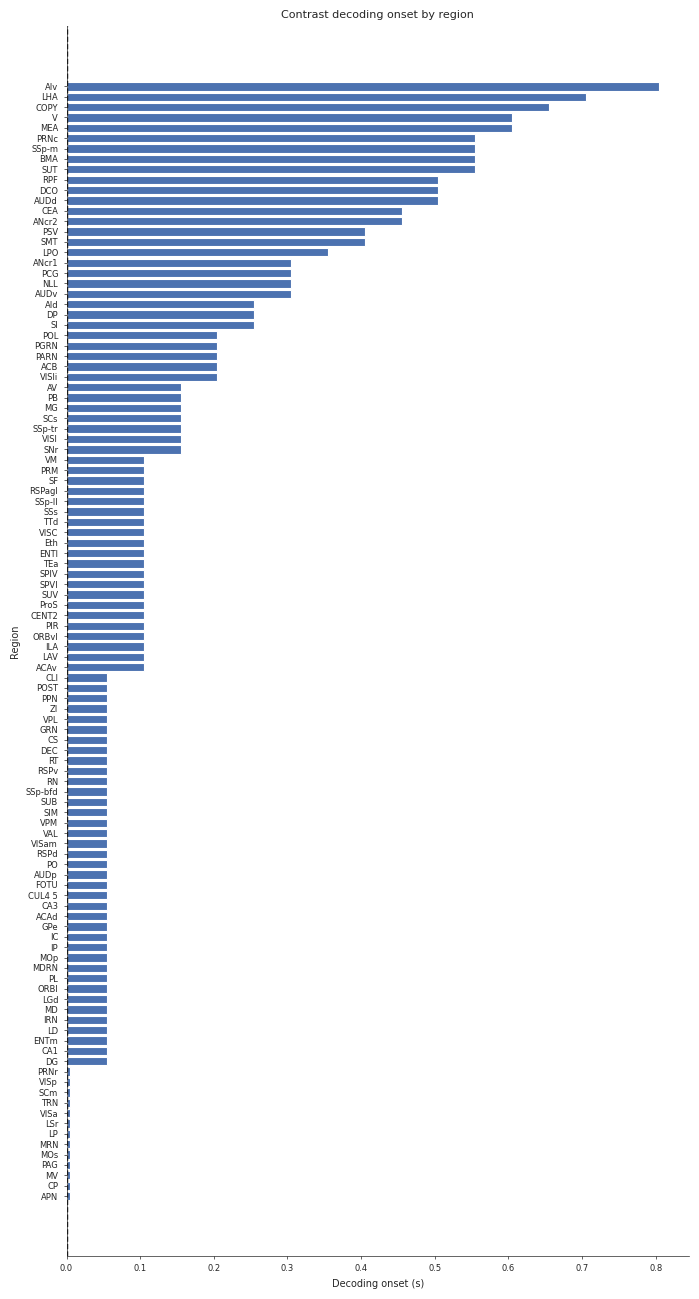

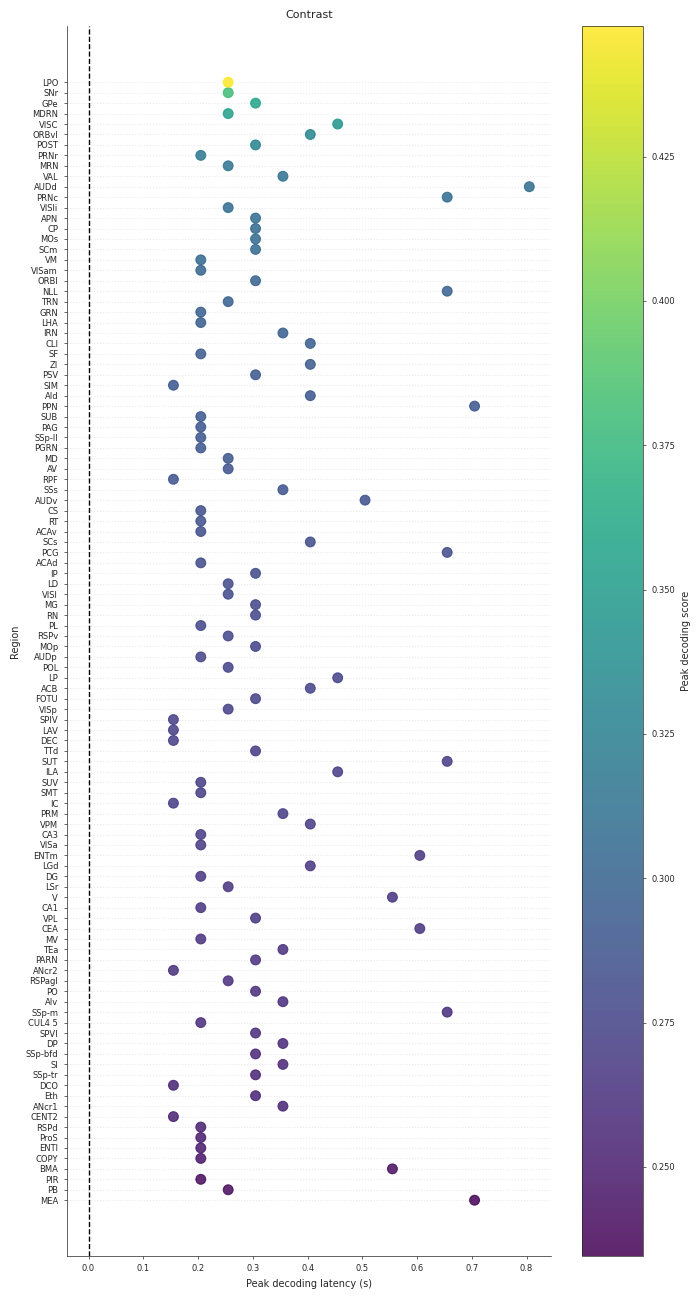

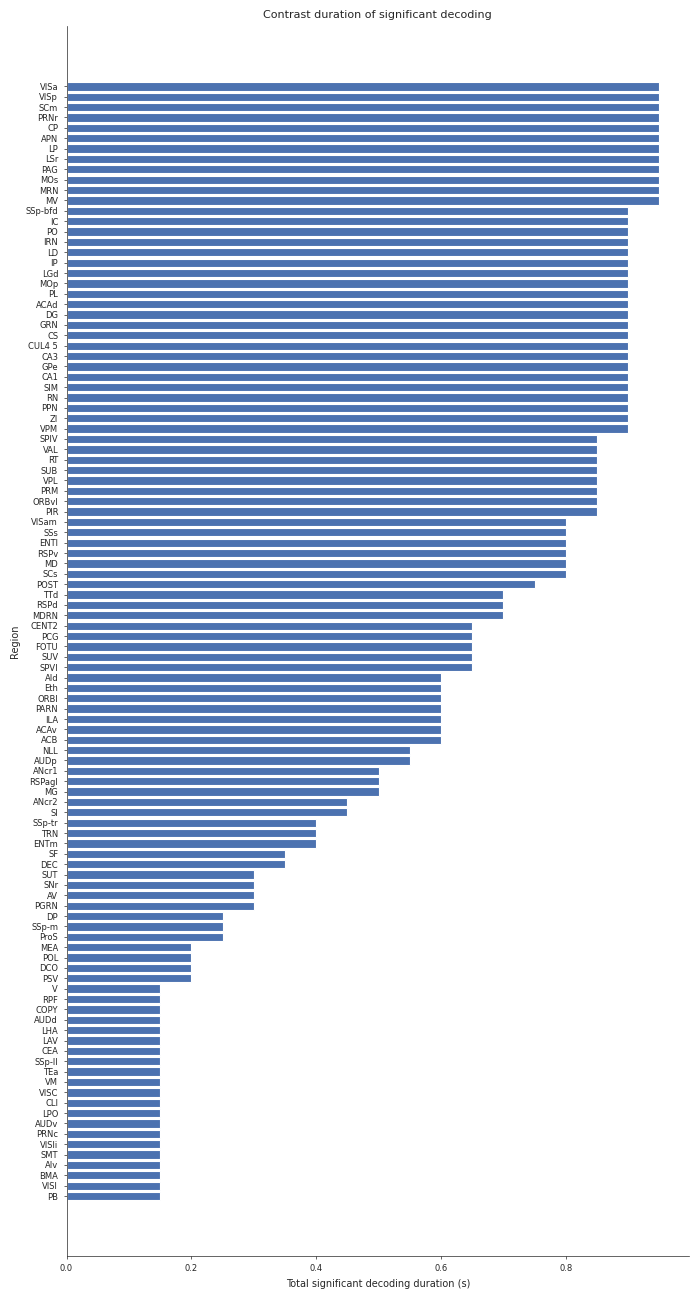

In [23]:
# CONTRAST
plot_decoding_onset(contrast_summary, title='Contrast')
plot_peak_decoding(contrast_summary, title='Contrast')
plot_decoding_duration(contrast_summary, title='Contrast')

### **Comparing Side and Contrast Summaries**

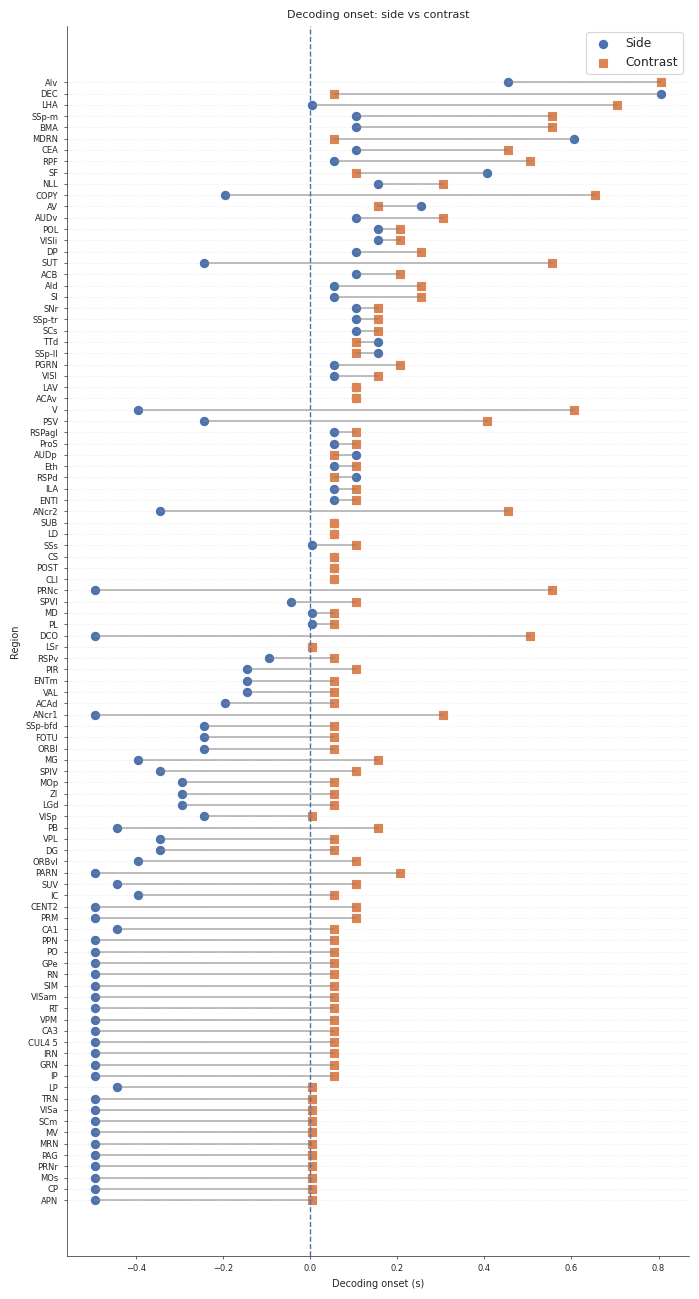

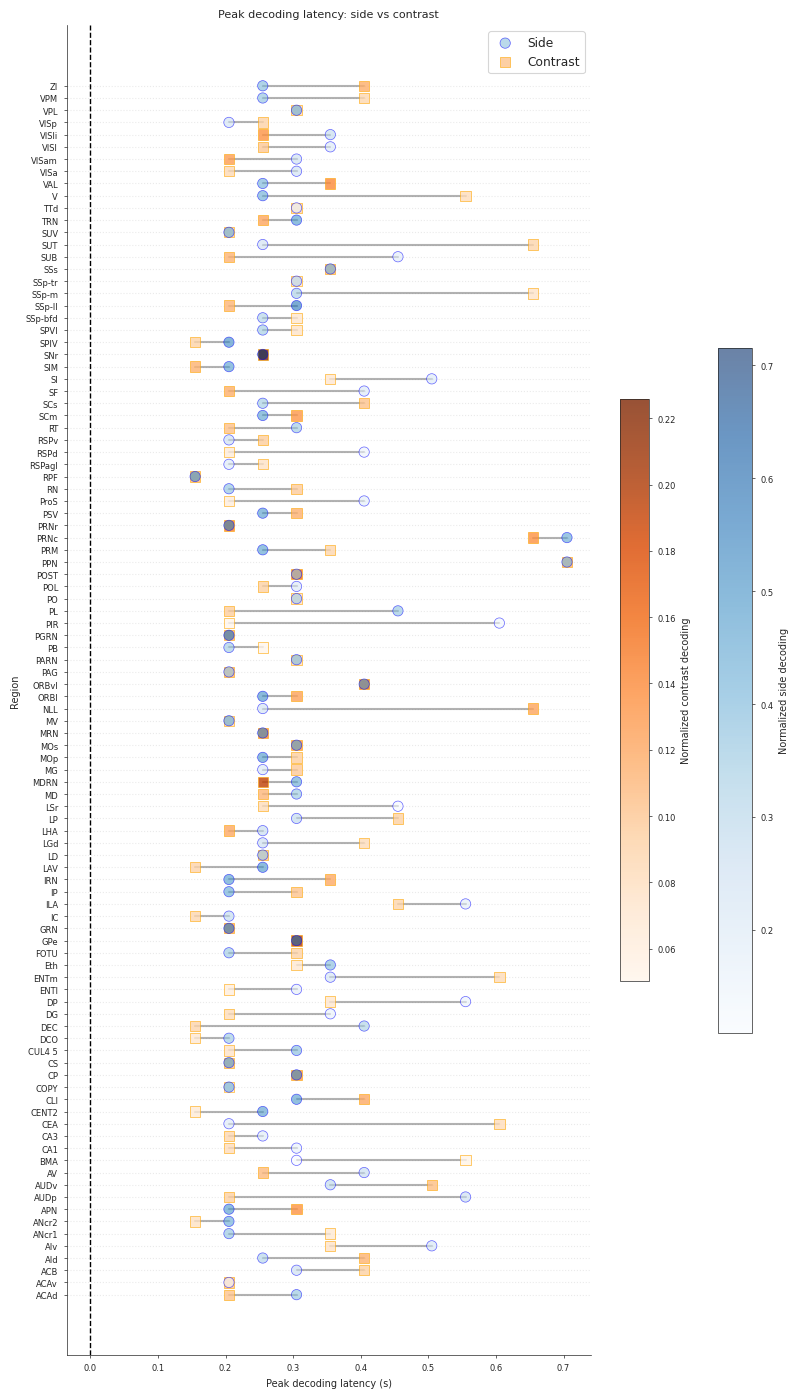

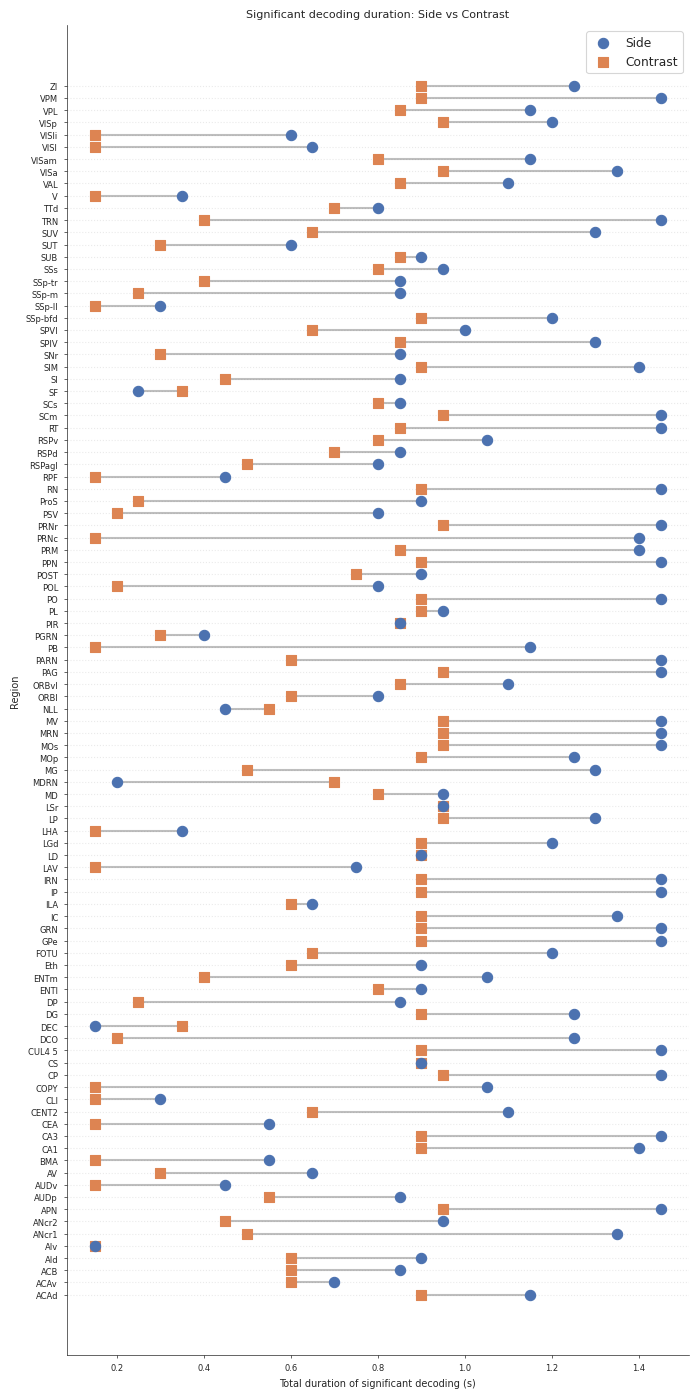

In [25]:
plot_onset_comparison(side_summary, contrast_summary)
plot_peak_comparison(side_summary, contrast_summary)
plot_duration_comparison(side_summary, contrast_summary)

In [ ]:
# !! You need to only save ONCE !!
comparison_table = create_side_contrast_table(side_summary, contrast_summary)
comparison_table.to_csv('../results/side_vs_contrast_summary.csv', index=False)

In [28]:
# Then rerun this cell to read the comparison results
comparison_table = pd.read_csv('../results/side_vs_contrast_summary.csv')
comparison_table

,region,side_onset,contrast_onset,side_offset,contrast_offset,side_duration,contrast_duration,side_peak_score,contrast_peak_score,side_peak_time,contrast_peak_time
0,ACAd,-0.195,0.055,0.955,0.955,1.15,0.90,0.682102,0.282026,0.305,0.205
1,ACAv,0.105,0.105,0.955,0.705,0.70,0.60,0.563251,0.282587,0.205,0.205
2,ACB,0.105,0.205,0.955,0.805,0.85,0.60,0.629393,0.274879,0.305,0.405
3,AId,0.055,0.255,0.955,0.855,0.90,0.60,0.655211,0.290682,0.255,0.405
4,AIp,-0.045,NaN,0.805,NaN,0.45,NaN,0.626379,NaN,0.505,NaN
...,...,...,...,...,...,...,...,...,...,...,...
138,VPL,-0.345,0.055,0.955,0.905,1.15,0.85,0.711918,0.265527,0.305,0.305
139,VPM,-0.495,0.055,0.955,0.955,1.45,0.90,0.685708,0.270243,0.255,0.405
140,VeCB,0.805,NaN,0.955,NaN,0.15,NaN,0.715776,NaN,0.205,NaN
141,ZI,-0.295,0.055,0.955,0.955,1.25,0.90,0.694847,0.292898,0.255,0.405
